# Sprites y diseño del resorte

El objetivo de este notebook es simplemente probar lineas y comandos para diseñar un resorte (graficamente)
Ademas de evaluar como podría ser posible hacer un tipo de objeto nuevo (a través de clases) para implementar
dicho diseño en animaciones.

In [1]:
# importamos librerias
import matplotlib.pyplot as plt
import numpy as np

## Trazos iniciales:

Se considerara para el diseno de superficies formadas por lineas rectas (conectadas entre si), que la clase en lugar de tener un argumento de dupla para la posicion, tendra un array con una formado por una serie de puntos que conectara a la superficie. Para las lineas que indican la parte alterna de la superficie, se buscara usar una forma de organizarlas similar a las lineas diagonales del resorte. Como sea, tomese de ejemplo la sig ilustracion de una superficie que va de (0.1,0.6) a (0.4,0.6), de ahi a (0.6,0.4), y de ahi a (0.9,0.4)

C:\Users\ornel\AppData\Local\Temp\ipykernel_2992\1432825065.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


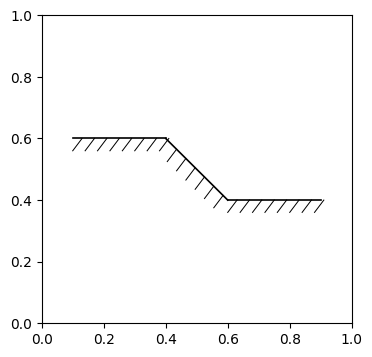

In [48]:
#plano
fig, ax = plt.subplots()
fig.set_size_inches(4,4)
ax.set_xlim(0,1)
ax.set_ylim(0,1)

#primer resorte
def sup1(w=1):
    #lineas de superficie
    ax.plot([0.1,0.4],[0.6,0.6],color="black", lw=w)
    ax.plot([0.4,0.6],[0.6,0.4],color="black", lw=w)
    ax.plot([0.6,0.9],[0.4,0.4],color="black", lw=w)

    #lineas de internas sup 1
    for x in np.arange(0.1,0.38,0.04):
        ax.plot([x,x+0.03],[0.56,0.6],color="black", lw=w*0.6)
    #lineas de internas sup 3
    for x in np.arange(0.6,0.88,0.04):
        ax.plot([x,x+0.03],[0.36,0.4],color="black", lw=w*0.6)
    #lineas de internas sup 2
    for x in np.arange(0.435,0.6,0.03):
        ax.plot([x,x-0.03],[-x+1,-x+0.96],color="black", lw=w*0.6)


sup1(w=1.2)
fig.show()

Hay varios problemas por resolver, por que si no fuera por un cuchareo a las lineas del interior de la segunda superficie, estas se verias muy pegadas. Tambien tenemos que modificar a traves de un parametro en que direccion se tienen que ilustrar las lineas, por si queremos ilustrar paredes o techos, por ejemplo

## Creacion de la clase

Los parametros a considerar van a ser \
1.- Los puntos sobre los cuales se ilustra la superficie \
2.- El peso (weight) que indique el grosor de los trazos \
3.- Direccion de las lineas que apuntan dentro de la superficie (lineas internas). Se usaran las palabras "tr" (top right), "br" (bottom right), "tl" (top left), y "bl" \
4.- Un factor de escala para indicar el tamaño y separacion de las lineas internas
5.- En caso de que queramos que se mueva, una variable de offset $\vec{p}$ para mover sus puntos con la transformacion $X+\vec{p}$ (El objeto no considera esta variable para draw, solo para reset)

Primero hagamos que dibuje las lineas de superficie

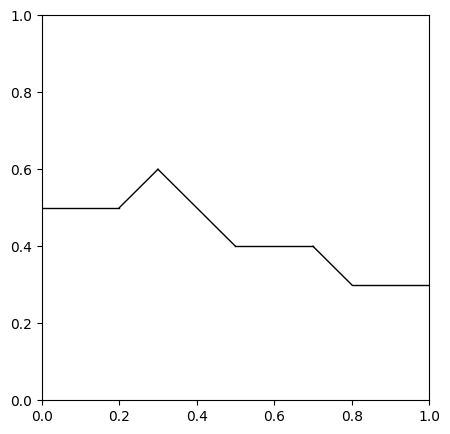

In [74]:
#plano
fig, ax = plt.subplots()
fig.set_size_inches(5,5)
ax.set_xlim(0,1)
ax.set_ylim(0,1)

class Surface:
    #función init
    def __init__(self, ax, pos=[(0,0),(1,0)], scale=1, weight=1, direction="br", offset=[(0,0),(0,0)]):
        self.ax = ax
        self.pos = pos
        self.scale = scale
        self.weight = weight
        self.direction = direction
        self.offset = offset

    def draw(self):
        # dibujamos las lineas de superficie
        #array para guardar las lineas
        surface_lines = []
        for i,point in enumerate(self.pos):
            if(i==0):
                #variable para guardar el punto actual y usarlo en la sig iteracion
                prev_point = point
                continue
            surface_lines.append( self.ax.plot([prev_point[0], point[0]], [prev_point[1], point[1]], color="black", lw=self.weight)[0])
            #actualizamos el punto anterior
            prev_point = point


#probamos dibujar con 7 lineas diagonales empezando en otra posicion
resorte = Surface(ax, pos=[(0,0.5),(0.2,0.5), (0.3,0.6), (0.5,0.4), (0.7,0.4), (0.8, 0.3), (1,0.3)])
resorte.draw()


Primero, para establecer las lineas internas diagonales, resulta necesario establecer sus dimensiones. Digamos que estas por default tendran un ancho en el eje X de $x$ y un alto en el eje Y de $y$. Esta claro que el par $x,y$ depende solo de la escala. Para que queden como en el primer sketch, si $w$ es el peso, $x = 0.3w, y = 0.4w$. Ahora bien, lo siguiente es elegir la separacion de dichas lineas. Se propone que, para que
queden como el sketch, la separacion de punta a punta sea de $d = x(1+a)$, con $a$ fija y en este caso 0.25. Ahora, como las puntas pasan sobre las lineas de superficie, y de estas podemos medir $l$, entonces para saber el numero de lineas internas por linea superficial, podemos simplemente tomar $n = l/d$, y redondearlo como creamos convieniente (como pasa con el resorte). Siguiendo ese camino 

l: 0.282842712474619, idd: 0.04, n: 7, d: 0.04040610178208843, i:1
l: 0.19999999999999996, idd: 0.04, n: 5, d: 0.039999999999999994, i:2
l: 0.1414213562373096, idd: 0.04, n: 4, d: 0.0353553390593274, i:3


C:\Users\ornel\AppData\Local\Temp\ipykernel_2992\1703082385.py:52: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


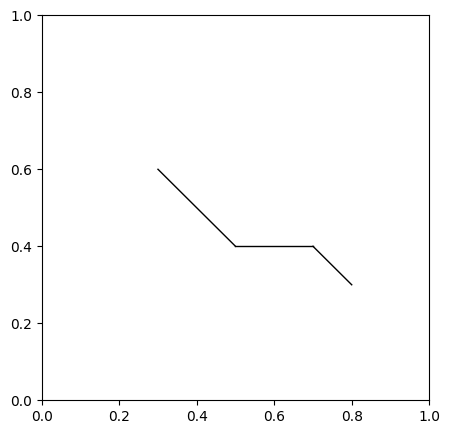

In [ ]:
#plano
fig, ax = plt.subplots()
fig.set_size_inches(5,5)
ax.set_xlim(0,1)
ax.set_ylim(0,1)

class Surface:
    #función init
    def __init__(self, ax, pos=[(0,0),(1,0)], scale=1, weight=1, direction="br", offset=[(0,0),(0,0)]):
        self.ax = ax
        self.pos = pos
        self.scale = scale
        self.weight = weight
        self.direction = direction
        self.offset = offset

    def draw(self):
        # dibujamos las lineas de superficie
        #array para guardar las lineas
        surface_lines = []
        #aray para guardar las lineas internas. Este tendra subsarrays para cada linea de superficie
        internal_lines = []
        #recorremos los puntos de la superficie
        for i,point in enumerate(self.pos):
            if(i==0):
                #variable para guardar el punto actual y usarlo en la sig iteracion
                prev_point = point
                continue
            surface_lines.append( self.ax.plot([prev_point[0], point[0]], [prev_point[1], point[1]], color="black", lw=self.weight)[0])
            
            #calculamos la cantidad de lineas internas a dibujar
            #calculamos la longitud de la superficie
            l = np.sqrt( (prev_point[0] - point[0])**2 + (prev_point[1] - point[1])**2 )
            # separacion de lineas ideal
            idd = self.scale*0.04
            # proporcion entre l y idd
            n = l/idd
            # redondeamos n al entero mas cercano
            n = int(round(n))
            #obtenemos con eso la separacion real entre lineas internas
            d = l/n
            #imprimimos los valores para ver
            print(f"l: {l}, idd: {idd}, n: {n}, d: {d}, i:{i}")


            #actualizamos el punto anterior
            prev_point = point

#probamos dibujar con 7 lineas diagonales empezando en otra posicion
resorte = Surface(ax, pos=[(0.3,0.6), (0.5,0.4), (0.7,0.4), (0.8, 0.3)])
resorte.draw()
fig.show()


Para empezar a dibujar las lineas internas, consideremos que, dados los dos puntos $\vec{p}$ y $\vec{q}$ en los extremos de la linea de superficie, tendremos que $\vec{s} = \vec{q} - \vec{p}$ sera un vector que apunta de uno al otro, y si lo dividimos entre $l$, este sera unitario. Ahora, notese que si en esa superficie tendremos n lineas interiores, si $j$ en natural de 1 a $n$, tendremos que:

$$
\vec{p} + jd\vec{s}/l = \vec{p} + j\vec{s}/n
$$

Sera la posicion de la j-esima linea sobre la linea de superficie. Notese que d es la separacion entre ellas.
Ahora solo dibujemos lineas hacia abajo para ver que todo sea correcto

C:\Users\ornel\AppData\Local\Temp\ipykernel_2992\3049732790.py:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


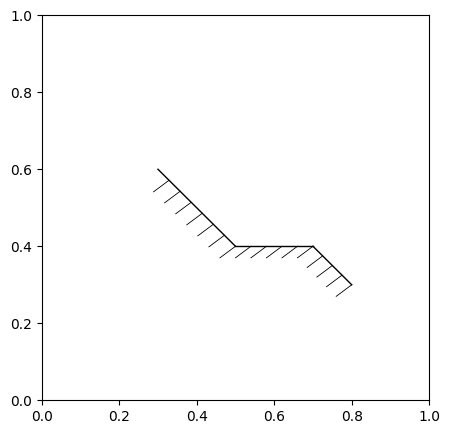

In [97]:
#plano
fig, ax = plt.subplots()
fig.set_size_inches(5,5)
ax.set_xlim(0,1)
ax.set_ylim(0,1)

class Surface:
    #función init
    def __init__(self, ax, pos=[(0,0),(1,0)], scale=1, weight=1, direction="br", offset=[(0,0),(0,0)]):
        self.ax = ax
        self.pos = pos
        self.scale = scale
        self.weight = weight
        self.direction = direction
        self.offset = offset

    def draw(self):
        # dibujamos las lineas de superficie
        #array para guardar las lineas
        surface_lines = []
        #aray para guardar las lineas internas. Este tendra subsarrays para cada linea de superficie
        internal_lines = []
        #recorremos los puntos de la superficie
        for i,point in enumerate(self.pos):
            if(i==0):
                #variable para guardar el punto actual y usarlo en la sig iteracion
                prev_point = point
                continue
            surface_lines.append( self.ax.plot([prev_point[0], point[0]], [prev_point[1], point[1]], color="black", lw=self.weight)[0])
            
            #calculamos la cantidad de lineas internas a dibujar
            #calculamos la longitud de la superficie
            l = np.sqrt( (prev_point[0] - point[0])**2 + (prev_point[1] - point[1])**2 )
            # separacion de lineas ideal
            idd = self.scale*0.04
            # proporcion entre l y idd
            n = l/idd
            # redondeamos n al entero mas cercano
            n = int(round(n))
            #obtenemos con eso la separacion real entre lineas internas
            d = l/n
            #imprimimos los valores para ver
            internal_lines.append([])
            for j in range(n):
                x = prev_point[0]+(point[0]-prev_point[0])*(j+1)/n
                y = prev_point[1]+(point[1]-prev_point[1])*(j+1)/n
                internal_lines[-1].append( self.ax.plot([x,x-self.scale*0.04], [y, y-self.scale*0.03], color="black", lw=self.weight*0.6)[0])


            #actualizamos el punto anterior
            prev_point = point

#probamos dibujar con 7 lineas diagonales empezando en otra posicion
sup = Surface(ax, pos=[(0.3,0.6), (0.5,0.4), (0.7,0.4), (0.8, 0.3)])
sup.draw()
fig.show()

Ahora, para hacer valer el parametro de direction, solo ponemos un condicional

C:\Users\ornel\AppData\Local\Temp\ipykernel_2992\2394153062.py:65: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


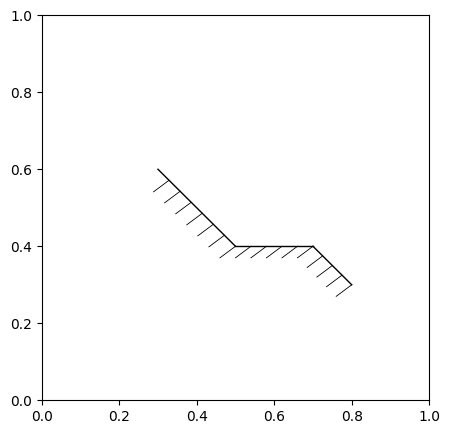

In [ ]:
#plano
fig, ax = plt.subplots()
fig.set_size_inches(5,5)
ax.set_xlim(0,1)
ax.set_ylim(0,1)

class Surface:
    #función init
    def __init__(self, ax, pos=[(0,0),(1,0)], scale=1, weight=1, direction="br", offset=[(0,0)]):
        self.ax = ax
        self.pos = pos
        self.scale = scale
        self.weight = weight
        self.direction = direction
        self.offset = offset

    def draw(self):
        # dibujamos las lineas de superficie
        #array para guardar las lineas
        surface_lines = []
        #aray para guardar las lineas internas. Este tendra subsarrays para cada linea de superficie
        internal_lines = []
        #recorremos los puntos de la superficie
        for i,point in enumerate(self.pos):
            if(i==0):
                #variable para guardar el punto actual y usarlo en la sig iteracion
                prev_point = point
                continue
            surface_lines.append( self.ax.plot([prev_point[0], point[0]], [prev_point[1], point[1]], color="black", lw=self.weight)[0])
            
            #calculamos la cantidad de lineas internas a dibujar
            #calculamos la longitud de la superficie
            l = np.sqrt( (prev_point[0] - point[0])**2 + (prev_point[1] - point[1])**2 )
            # separacion de lineas ideal
            idd = self.scale*0.04
            # proporcion entre l y idd
            n = l/idd
            # redondeamos n al entero mas cercano
            n = int(round(n))
            #obtenemos con eso la separacion real entre lineas internas
            d = l/n
            #imprimimos los valores para ver
            internal_lines.append([])
            for j in range(n):
                x = prev_point[0]+(point[0]-prev_point[0])*(j+1)/n
                y = prev_point[1]+(point[1]-prev_point[1])*(j+1)/n
                #Agregamos condiciones para br, bl, tr y tl
                if(self.direction == "br"):
                    internal_lines[-1].append( self.ax.plot([x,x-self.scale*0.04], [y, y-self.scale*0.03], color="black", lw=self.weight*0.6)[0])
                elif(self.direction == "bl"):
                    internal_lines[-1].append( self.ax.plot([x,x+self.scale*0.04], [y, y-self.scale*0.03], color="black", lw=self.weight*0.6)[0])
                elif(self.direction == "tr"):
                    internal_lines[-1].append( self.ax.plot([x,x-self.scale*0.04], [y, y+self.scale*0.03], color="black", lw=self.weight*0.6)[0])
                elif(self.direction == "tl"):
                    internal_lines[-1].append( self.ax.plot([x,x+self.scale*0.04], [y, y+self.scale*0.03], color="black", lw=self.weight*0.6)[0])
                else:
                    raise Exception("non valid direction")

            #actualizamos el punto anterior
            prev_point = point

#probamos dibujar con 7 lineas diagonales empezando en otra posicion
sup = Surface(ax, pos=[(0.3,0.6), (0.5,0.4), (0.7,0.4), (0.8, 0.3)], direction="br")
sup.draw()
fig.show()

## Resultado / Orientacion (Offset)

Finalmente agregamos la opcion de desplazar la superficie con el parametro offset usando la funcion reset. Notese que solo tendra que sumarse
las cordenadas a los puntos ya usados.

C:\Users\ornel\AppData\Local\Temp\ipykernel_2992\2960910598.py:93: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


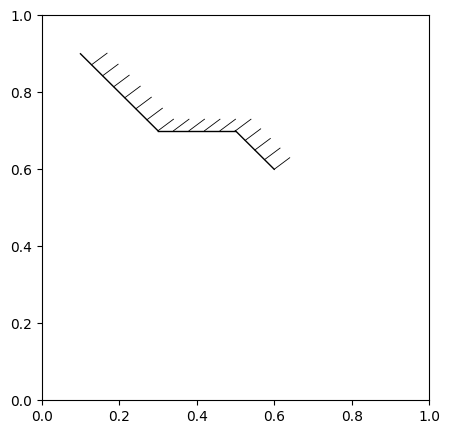

In [118]:
#plano
fig, ax = plt.subplots()
fig.set_size_inches(5,5)
ax.set_xlim(0,1)
ax.set_ylim(0,1)

class Surface:
    #función init
    def __init__(self, ax, pos=[(0,0),(1,0)], scale=1, weight=1, direction="br", offset=(0,0)):
        self.ax = ax
        self.pos = pos
        self.scale = scale
        self.weight = weight
        self.direction = direction
        self.offset = offset

    def draw(self):
        # dibujamos las lineas de superficie
        #array para guardar las lineas
        self.surface_lines = []
        #aray para guardar las lineas internas. Este tendra subsarrays para cada linea de superficie
        self.internal_lines = []
        #recorremos los puntos de la superficie
        for i,point in enumerate(self.pos):
            if(i==0):
                #variable para guardar el punto actual y usarlo en la sig iteracion
                prev_point = point
                continue
            self.surface_lines.append( self.ax.plot([prev_point[0], point[0]], [prev_point[1], point[1]], color="black", lw=self.weight)[0])
            
            #calculamos la cantidad de lineas internas a dibujar
            #calculamos la longitud de la superficie
            l = np.sqrt( (prev_point[0] - point[0])**2 + (prev_point[1] - point[1])**2 )
            # separacion de lineas ideal
            idd = self.scale*0.04
            # proporcion entre l y idd
            n = l/idd
            # redondeamos n al entero mas cercano
            n = int(round(n))
            #obtenemos con eso la separacion real entre lineas internas
            d = l/n
            #imprimimos los valores para ver
            self.internal_lines.append([])
            for j in range(n):
                x = prev_point[0]+(point[0]-prev_point[0])*(j+1)/n
                y = prev_point[1]+(point[1]-prev_point[1])*(j+1)/n
                #Agregamos condiciones para br, bl, tr y tl
                if(self.direction == "br"):
                    self.internal_lines[-1].append( self.ax.plot([x,x-self.scale*0.04], [y, y-self.scale*0.03], color="black", lw=self.weight*0.6)[0])
                elif(self.direction == "bl"):
                    self.internal_lines[-1].append( self.ax.plot([x,x+self.scale*0.04], [y, y-self.scale*0.03], color="black", lw=self.weight*0.6)[0])
                elif(self.direction == "tr"):
                    self.internal_lines[-1].append( self.ax.plot([x,x-self.scale*0.04], [y, y+self.scale*0.03], color="black", lw=self.weight*0.6)[0])
                elif(self.direction == "tl"):
                    self.internal_lines[-1].append( self.ax.plot([x,x+self.scale*0.04], [y, y+self.scale*0.03], color="black", lw=self.weight*0.6)[0])
                else:
                    raise Exception("non valid direction")

            #actualizamos el punto anterior
            prev_point = point
        
    def reset(self,offset):
        self.offset = offset
        # Recorremos las lineas de superficie:
        for i,line in enumerate(self.surface_lines):
            # Obtenemos los puntos originales de la línea
            xdata = line.get_xdata()
            ydata = line.get_ydata()
            # Calculamos el nuevo punto de inicio y fin con el offset
            new_xdata = [x + self.offset[0] for x in xdata]
            new_ydata = [y + self.offset[1] for y in ydata]
            # Actualizamos los datos de la línea
            line.set_xdata(new_xdata)
            line.set_ydata(new_ydata)
                # Recorremos las lineas internas
            for internal_line in self.internal_lines[i]:
                # Obtenemos los puntos originales de la línea interna
                xdata = internal_line.get_xdata()
                ydata = internal_line.get_ydata()
                # Calculamos el nuevo punto de inicio y fin con el offset
                new_xdata = [x + self.offset[0] for x in xdata]
                new_ydata = [y + self.offset[1] for y in ydata]
                # Actualizamos los datos de la línea interna
                internal_line.set_xdata(new_xdata)
                internal_line.set_ydata(new_ydata)



#probamos dibujar con 7 lineas diagonales empezando en otra posicion
sup = Surface(ax, pos=[(0.3,0.6), (0.5,0.4), (0.7,0.4), (0.8, 0.3)], direction="tl")
sup.draw()
sup.reset(offset=(-0.2,0.3))
fig.show()